✅ Success: CSV and Excel files created!

--- Summary Statistics ---


,Age,Cholesterol
Heart_Disease,,
Absence,56.309091,297.454545
Presence,51.333333,288.266667


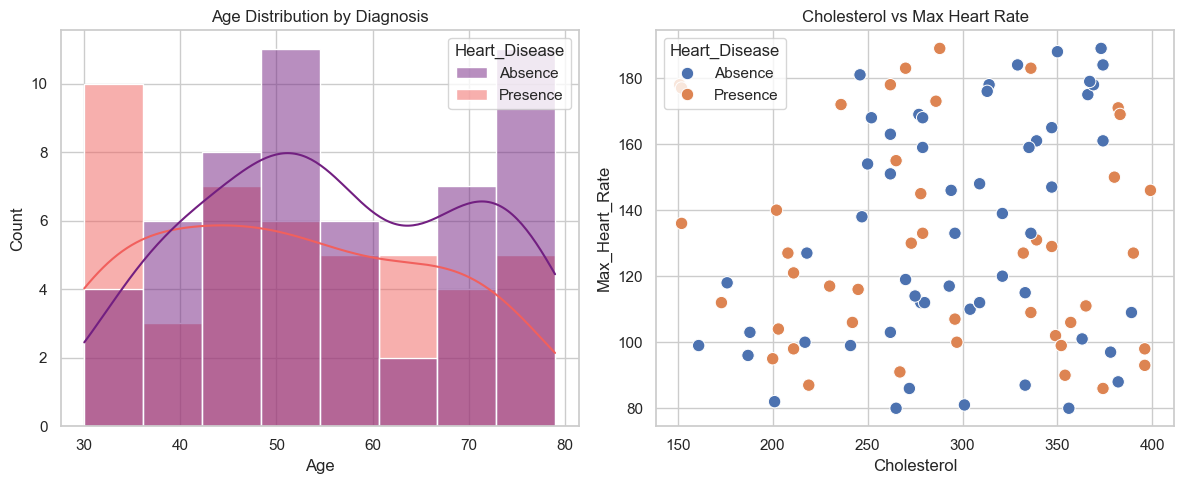

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 1: GENERATE DATA ---
np.random.seed(42)
n_samples = 100
data = {
    'Patient_ID': [f'P-{1000+i}' for i in range(n_samples)],
    'Age': np.random.randint(30, 80, size=n_samples),
    'Sex': np.random.choice(['Male', 'Female'], size=n_samples),
    'Cholesterol': np.random.randint(150, 400, size=n_samples),
    'Max_Heart_Rate': np.random.randint(80, 190, size=n_samples),
    'Resting_BP': np.random.randint(100, 180, size=n_samples),
    'Heart_Disease': np.random.choice(['Presence', 'Absence'], size=n_samples)
}

df = pd.DataFrame(data)

# Save files
df.to_csv('heart_disease_patients_100.csv', index=False)
df.to_excel('heart_disease_patients_100.xlsx', index=False)
print("✅ Success: CSV and Excel files created!")

# --- STEP 2: DATA ANALYSIS ---
print("\n--- Summary Statistics ---")
display(df.groupby('Heart_Disease')[['Age', 'Cholesterol']].mean())

# --- STEP 3: VISUALIZATION ---
plt.figure(figsize=(12, 5))

# Plot 1: Age Distribution
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Age', hue='Heart_Disease', kde=True, palette='magma')
plt.title('Age Distribution by Diagnosis')

# Plot 2: Cholesterol vs Heart Rate
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Cholesterol', y='Max_Heart_Rate', hue='Heart_Disease', s=80)
plt.title('Cholesterol vs Max Heart Rate')

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the data
df = pd.read_csv('heart_disease_patients_100.csv')

# 1. High-level info
print("--- Dataset Info ---")
df.info()

# 2. Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# 3. Descriptive Statistics
print("\n--- Statistical Summary ---")
display(df.describe())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Patient_ID      100 non-null    object
 1   Age             100 non-null    int64 
 2   Sex             100 non-null    object
 3   Cholesterol     100 non-null    int64 
 4   Max_Heart_Rate  100 non-null    int64 
 5   Resting_BP      100 non-null    int64 
 6   Heart_Disease   100 non-null    object
dtypes: int64(4), object(3)
memory usage: 5.6+ KB

--- Missing Values ---
Patient_ID        0
Age               0
Sex               0
Cholesterol       0
Max_Heart_Rate    0
Resting_BP        0
Heart_Disease     0
dtype: int64

--- Statistical Summary ---


,Age,Cholesterol,Max_Heart_Rate,Resting_BP
count,100.000000,100.000000,100.000000,100.000000
mean,54.070000,293.320000,131.500000,138.260000
std,14.447575,65.534613,32.859204,20.237788
min,30.000000,151.000000,80.000000,101.000000
25%,43.000000,249.250000,103.000000,120.500000
50%,53.000000,295.000000,127.000000,141.500000
75%,68.000000,347.500000,161.500000,157.000000
max,79.000000,399.000000,189.000000,175.000000


KeyError: 'Heart_Disease_Diagnosis'

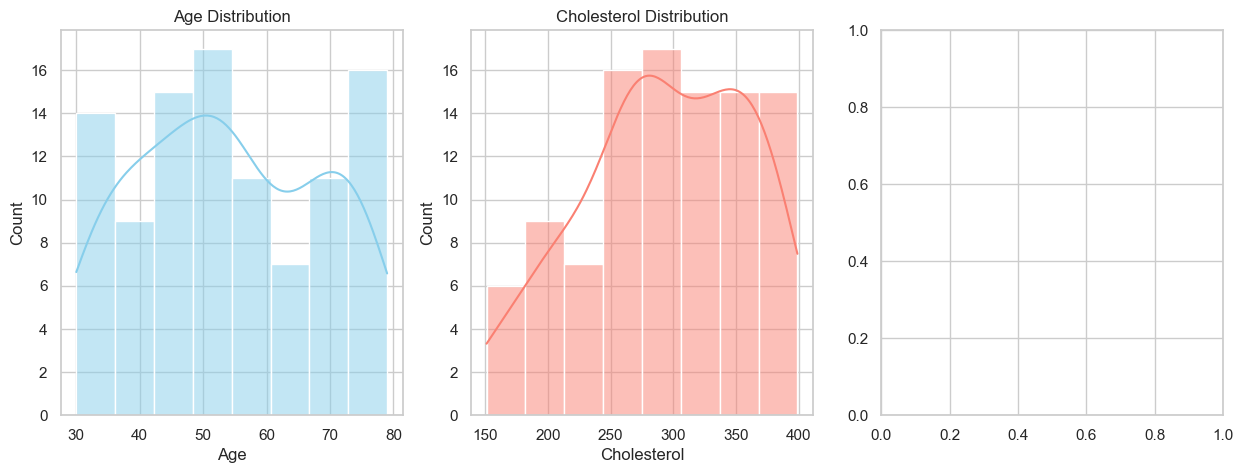

In [9]:
plt.figure(figsize=(15, 5))

# Plot Age Distribution
plt.subplot(1, 3, 1)
sns.histplot(df['Age'], kde=True, color='skyblue')
plt.title('Age Distribution')

# Plot Cholesterol Distribution
plt.subplot(1, 3, 2)
sns.histplot(df['Cholesterol'], kde=True, color='salmon')
plt.title('Cholesterol Distribution')

# Plot Diagnosis Count
plt.subplot(1, 3, 3)
df['Heart_Disease_Diagnosis'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Diagnosis Ratio')

plt.tight_layout()
plt.show()

Simple Regression R2 Score: -0.16


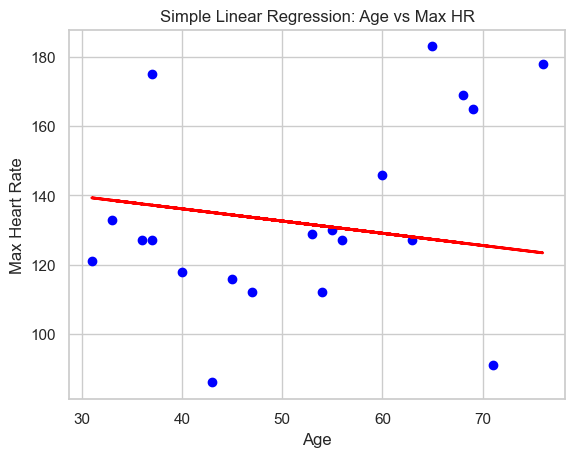

In [12]:
# 1. Prepare Data
X = df[['Age']] # Feature (Independent variable)
y = df['Max_Heart_Rate'] # Target (Dependent variable)

# 2. Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create and Train Model
simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

# 4. Predict and Evaluate
y_pred = simple_model.predict(X_test)
print(f"Simple Regression R2 Score: {r2_score(y_test, y_pred):.2f}")

# Visualize the Line of Best Fit
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, y_pred, color='red', linewidth=2)
plt.title('Simple Linear Regression: Age vs Max HR')
plt.xlabel('Age')
plt.ylabel('Max Heart Rate')
plt.show()

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# 1. Load your generated data
df = pd.read_csv('heart_disease_patients_100.csv')

# 2. Define Features (X) and Target (y)
# We want to see how Age, Cholesterol, and BP affect Max Heart Rate
X = df[['Age', 'Cholesterol', 'Resting_BP']]
y = df['Max_Heart_Rate']

# 3. Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Make Predictions on the test set
y_pred = model.predict(X_test)

# 6. Evaluate the Model
print("--- Model Coefficients ---")
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coeff_df)

print("\n--- Performance Metrics ---")
print(f"Intercept: {model.intercept_:.2f}")
print(f"Mean Absolute Error (MAE): {metrics.mean_absolute_error(y_test, y_pred):.2f}")
print(f"R-squared Score: {metrics.r2_score(y_test, y_pred):.2f}")

--- Model Coefficients ---
             Coefficient
Age            -0.396362
Cholesterol     0.069865
Resting_BP     -0.072629

--- Performance Metrics ---
Intercept: 141.76
Mean Absolute Error (MAE): 22.04
R-squared Score: -0.17


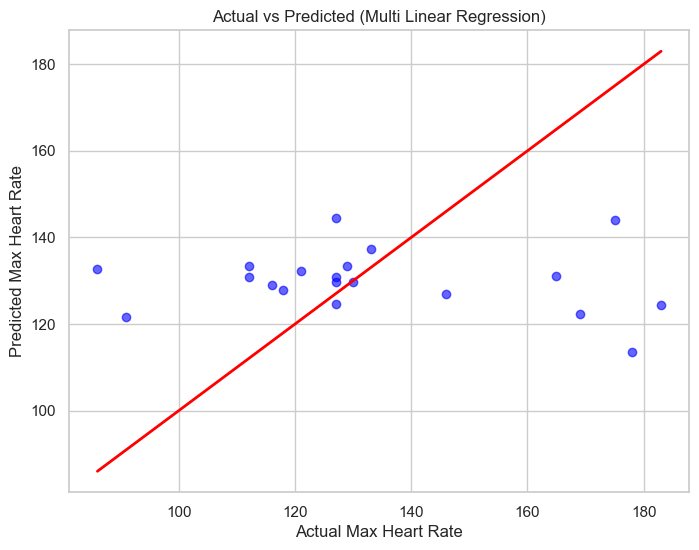

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2) # Diagonal line
plt.xlabel('Actual Max Heart Rate')
plt.ylabel('Predicted Max Heart Rate')
plt.title('Actual vs Predicted (Multi Linear Regression)')
plt.show()